# NB01 — Ekstraksi Fitur Wajah

**Tujuan:** Mendeteksi dan mengekstraksi face embedding dari dataset foto baru  
**Model:** InsightFace `buffalo_l` → embedding 512-dimensi  
**Output:** `embeddings.npy`, `metadata.pkl`  

---

**Alur:**
```
Foto (JPG/PNG/...)
  → InsightFace buffalo_l
  → deteksi bbox + ekstraksi embedding (512-dim)
  → simpan ke file
```

## 0. Instalasi & Import

In [ ]:
# Colab: pastikan runtime sudah diset ke GPU (T4/A100) sebelum run
!pip install insightface onnxruntime-gpu opencv-python-headless pillow pillow-heif tqdm rawpy -q

In [ ]:
import os
import pickle
import warnings
from pathlib import Path
from collections import Counter

import cv2
import insightface
import matplotlib.pyplot as plt
import numpy as np
from insightface.app import FaceAnalysis
from PIL import Image
from pillow_heif import register_heif_opener
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# Aktifkan HEIC/HEIF support sejak awal (iPhone photos)
register_heif_opener()

# Verifikasi GPU
import onnxruntime as ort
providers = ort.get_available_providers()
has_gpu = 'CUDAExecutionProvider' in providers
print(f"InsightFace version : {insightface.__version__}")
print(f"ONNX providers      : {providers}")
print(f"GPU tersedia        : {'YA (CUDA)' if has_gpu else 'TIDAK — ganti runtime ke GPU di Colab'}")
print(f"HEIC support        : aktif (pillow-heif)")

## 1. Konfigurasi

In [ ]:
# ─── SESUAIKAN PATH INI ──────────────────────────────────────────────────────
DATA_DIR   = Path("/content/drive/MyDrive/OTW S.KOM/Genbi")  # folder foto di Google Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb01")  # output disimpan di sini
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Format foto yang didukung (termasuk HEIC iPhone + RAW kamera)
SUPPORTED_EXT = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif",   # format umum
    ".heic", ".heif",                                              # iPhone (iOS 11+)
    ".raf", ".cr2", ".nef", ".arw", ".dng", ".rw2", ".orf",      # RAW kamera
}

# InsightFace config
DET_SIZE   = (640, 640)  # ukuran input detection
DET_THRESH = 0.35        # threshold deteksi wajah — diturunkan dari 0.5 agar wajah
                         # kecil/blur/sudut ekstrem (foto grup jarak jauh) tetap terdeteksi
CTX_ID     = 0 if has_gpu else -1  # auto: GPU jika tersedia, fallback CPU

print(f"Dataset dir : {DATA_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Path exists : {DATA_DIR.exists()}")
print(f"Device      : {'GPU (CUDA)' if CTX_ID == 0 else 'CPU'}")
print(f"DET_THRESH  : {DET_THRESH}  (lebih rendah = lebih sensitif, tapi mungkin ada false positive)")

In [3]:
# Jika pakai Google Drive — jalankan cell ini
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 2. Load Daftar Foto

In [15]:
# Diagnostik: lihat semua ekstensi di dataset
from collections import Counter
all_files = list(DATA_DIR.rglob("*"))
ext_counter = Counter(
    p.suffix.lower() for p in all_files
    if p.is_file() and not p.name.startswith("._")
)
print("Semua ekstensi file di dataset:")
for ext, count in ext_counter.most_common():
    mark = "✅" if ext in SUPPORTED_EXT else "❌ (tidak dibaca)"
    print(f"  {ext or '(no ext)':12s}  {count:4d}x  {mark}")

# Load foto dengan ekstensi yang didukung
all_photos = sorted([
    p for p in all_files
    if p.is_file()
    and p.suffix.lower() in SUPPORTED_EXT
    and not p.name.startswith("._")  # skip macOS metadata files
])

print(f"\nTotal foto akan diproses : {len(all_photos)}")
print(f"Contoh 5 foto pertama:")
for p in all_photos[:5]:
    print(f"  {p.relative_to(DATA_DIR)}")


Semua ekstensi file di dataset:
  .jpg           843x  ✅
  .raf            20x  ✅

Total foto akan diproses : 863
Contoh 5 foto pertama:
  262_FUJI/AIII2001.JPG
  262_FUJI/AIII2002.JPG
  262_FUJI/AIII2003.JPG
  262_FUJI/AIII2004.JPG
  262_FUJI/AIII2005.JPG


## 3. Inisialisasi Model InsightFace

In [8]:
face_app = FaceAnalysis(
    name="buffalo_l",
    allowed_modules=["detection", "recognition"],
)
face_app.prepare(ctx_id=CTX_ID, det_size=DET_SIZE, det_thresh=DET_THRESH)

print("Model buffalo_l berhasil dimuat.")
print("Dimensi embedding : 512")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:08<00:00, 34874.42KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

## 4. Ekstraksi Embedding

> Satu foto bisa menghasilkan **beberapa** embedding jika ada lebih dari satu wajah (foto grup).

In [ ]:
embeddings_list = []   # List[np.array(512,)]
metadata_list   = []   # List[dict]

# Log foto yang di-skip — untuk diagnostik
no_face_log = []   # List[str] nama file tanpa wajah terdeteksi
error_log   = []   # List[tuple(nama_file, pesan_error)]

stats = {
    "total_photos"    : len(all_photos),
    "photos_with_face": 0,
    "photos_no_face"  : 0,
    "photos_error"    : 0,
    "total_faces"     : 0,
}

for photo_path in tqdm(all_photos, desc="Ekstraksi wajah"):
    try:
        img = cv2.imread(str(photo_path))
        if img is None:
            # Fallback via PIL untuk format yang tidak didukung OpenCV
            pil_img = Image.open(photo_path).convert("RGB")
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        faces = face_app.get(img)

        if len(faces) == 0:
            stats["photos_no_face"] += 1
            no_face_log.append(str(photo_path.relative_to(DATA_DIR)))
            continue

        stats["photos_with_face"] += 1
        stats["total_faces"]      += len(faces)

        for face_idx, face in enumerate(faces):
            emb = face.normed_embedding   # L2-normalized, shape (512,)
            embeddings_list.append(emb)
            metadata_list.append({
                "photo_path" : str(photo_path),
                "photo_name" : photo_path.name,
                "face_idx"   : face_idx,
                "bbox"       : face.bbox.tolist(),    # [x1, y1, x2, y2]
                "det_score"  : float(face.det_score),
            })

    except Exception as e:
        stats["photos_error"] += 1
        error_log.append((str(photo_path.relative_to(DATA_DIR)), str(e)))
        print(f"[ERROR] {photo_path.name}: {e}")

print("\nEkstraksi selesai!")
print(f"  Foto total          : {stats['total_photos']}")
print(f"  Foto ada wajah      : {stats['photos_with_face']}")
print(f"  Foto tanpa wajah    : {stats['photos_no_face']}")
print(f"  Foto error          : {stats['photos_error']}")
print(f"  Total wajah (face)  : {stats['total_faces']}")

### 4b. Laporan Foto yang Tidak Termuat

In [ ]:
# ── Laporan foto tanpa wajah ───────────────────────────────────────────────────
print(f"{'='*56}")
print(f"  FOTO TIDAK TERMUAT — DIAGNOSTIK")
print(f"{'='*56}")

print(f"\n[Tanpa Wajah] {len(no_face_log)} foto — wajah tidak terdeteksi:")
for name in no_face_log[:30]:
    print(f"  • {name}")
if len(no_face_log) > 30:
    print(f"  ... dan {len(no_face_log) - 30} foto lainnya")

if error_log:
    print(f"\n[Error] {len(error_log)} foto — gagal dibaca:")
    for name, err in error_log[:15]:
        print(f"  • {name}")
        print(f"    ↳ {err}")
else:
    print(f"\n[Error] Tidak ada foto yang gagal dibaca.")

# Simpan log ke file CSV untuk referensi
import csv
log_path = OUTPUT_DIR / "skipped_photos_log.csv"
with open(log_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["foto", "alasan", "detail"])
    for name in no_face_log:
        writer.writerow([name, "no_face", ""])
    for name, err in error_log:
        writer.writerow([name, "error", err])

print(f"\nLog tersimpan: {log_path}  ({len(no_face_log) + len(error_log)} entri)")
print(f"{'='*56}")

## 5. Konversi ke Array & Verifikasi L2-Norm

In [17]:
embeddings = np.array(embeddings_list)   # shape: (N_faces, 512)

print(f"Shape embeddings : {embeddings.shape}")
print(f"Dtype            : {embeddings.dtype}")

# Verifikasi normalisasi L2 — penting untuk cosine similarity
norms = np.linalg.norm(embeddings, axis=1)
print(f"\nVerifikasi L2-norm (harusnya ≈ 1.0):")
print(f"  Min  : {norms.min():.6f}")
print(f"  Max  : {norms.max():.6f}")
print(f"  Mean : {norms.mean():.6f}")

if norms.max() - norms.min() < 0.01:
    print("  ✅ Embedding sudah L2-normalized — aman digunakan langsung untuk cosine similarity")
else:
    print("  ⚠️  Perlu normalisasi manual sebelum cosine similarity")

# Rata-rata wajah per foto
n_with_face = stats['photos_with_face']
avg_faces = stats['total_faces'] / n_with_face if n_with_face > 0 else 0
print(f"\nRata-rata wajah per foto : {avg_faces:.2f}")

Shape embeddings : (9677, 512)
Dtype            : float32

Verifikasi L2-norm (harusnya ≈ 1.0):
  Min  : 1.000000
  Max  : 1.000000
  Mean : 1.000000
  ✅ Embedding sudah L2-normalized — aman digunakan langsung untuk cosine similarity

Rata-rata wajah per foto : 11.49


## 6. Simpan Output

In [18]:
emb_path  = OUTPUT_DIR / "embeddings.npy"
meta_path = OUTPUT_DIR / "metadata.pkl"

np.save(emb_path, embeddings)
with open(meta_path, "wb") as f:
    pickle.dump(metadata_list, f)

print(f"Tersimpan:")
print(f"  {emb_path}  ({emb_path.stat().st_size / 1024:.1f} KB)")
print(f"  {meta_path}  ({meta_path.stat().st_size / 1024:.1f} KB)")

Tersimpan:
  /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb01/embeddings.npy  (19354.1 KB)
  /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb01/metadata.pkl  (756.8 KB)


## 7. Analisis & Visualisasi

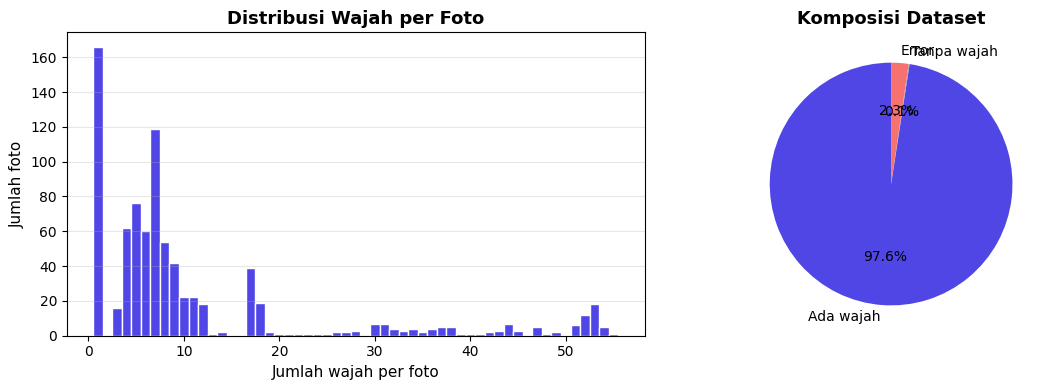

Statistik wajah per foto — Min: 1, Max: 55, Mean: 11.49


In [19]:
# ── 7a. Distribusi jumlah wajah per foto ──────────────────────────────────────
faces_per_photo = Counter(m["photo_name"] for m in metadata_list)
face_counts = list(faces_per_photo.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(face_counts, bins=range(1, max(face_counts) + 2),
             color="#4F46E5", edgecolor="white", align="left")
axes[0].set_xlabel("Jumlah wajah per foto", fontsize=11)
axes[0].set_ylabel("Jumlah foto", fontsize=11)
axes[0].set_title("Distribusi Wajah per Foto", fontsize=13, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

pie_data   = [stats["photos_with_face"], stats["photos_no_face"], stats["photos_error"]]
pie_labels = ["Ada wajah", "Tanpa wajah", "Error"]
pie_colors = ["#4F46E5", "#94A3B8", "#F87171"]
axes[1].pie(
    [v for v in pie_data if v > 0],
    labels=[l for v, l in zip(pie_data, pie_labels) if v > 0],
    colors=[c for v, c in zip(pie_data, pie_colors) if v > 0],
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10}
)
axes[1].set_title("Komposisi Dataset", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_wajah.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Statistik wajah per foto — Min: {min(face_counts)}, "
      f"Max: {max(face_counts)}, Mean: {np.mean(face_counts):.2f}")

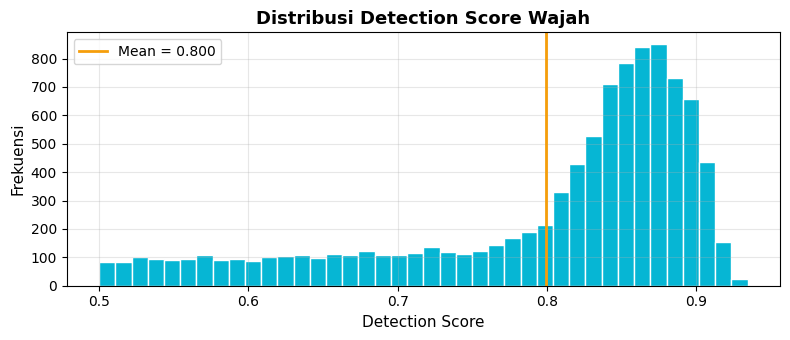

In [20]:
# ── 7b. Distribusi detection score ────────────────────────────────────────────
det_scores = [m["det_score"] for m in metadata_list]

plt.figure(figsize=(8, 3.5))
plt.hist(det_scores, bins=40, color="#06B6D4", edgecolor="white")
plt.axvline(np.mean(det_scores), color="#F59E0B", linewidth=2,
            label=f"Mean = {np.mean(det_scores):.3f}")
plt.xlabel("Detection Score", fontsize=11)
plt.ylabel("Frekuensi", fontsize=11)
plt.title("Distribusi Detection Score Wajah", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "det_score_dist.png", dpi=150, bbox_inches="tight")
plt.show()

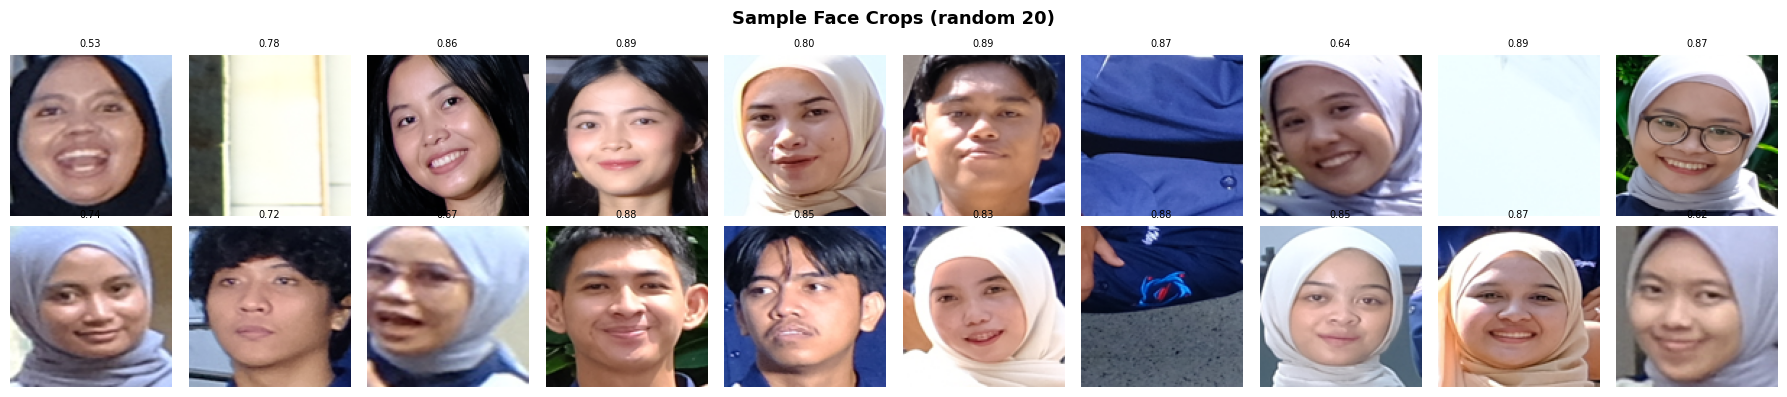

In [21]:
# ── 7c. Preview: sample face crops ────────────────────────────────────────────
def crop_face(photo_path, bbox, padding=0.2):
    img = Image.open(photo_path).convert("RGB")
    W, H = img.size
    x1, y1, x2, y2 = bbox
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, x1 - bw * padding)
    y1 = max(0, y1 - bh * padding)
    x2 = min(W, x2 + bw * padding)
    y2 = min(H, y2 + bh * padding)
    return img.crop((x1, y1, x2, y2)).resize((112, 112))

np.random.seed(42)
n_preview = min(20, len(metadata_list))
sample_idx = np.random.choice(len(metadata_list), n_preview, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Sample Face Crops (random 20)", fontsize=13, fontweight="bold")

for i, idx in enumerate(sample_idx):
    ax = axes[i // 10, i % 10]
    try:
        m = metadata_list[idx]
        ax.imshow(crop_face(m["photo_path"], m["bbox"]))
        ax.set_title(f"{m['det_score']:.2f}", fontsize=7)
    except Exception:
        ax.text(0.5, 0.5, "err", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_crops.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Ringkasan

In [22]:
coverage_pct = stats['photos_with_face'] / stats['total_photos'] * 100

print("=" * 52)
print("  RINGKASAN NB01 — EKSTRAKSI FITUR")
print("=" * 52)
print(f"  Total foto input     : {stats['total_photos']:,}")
print(f"  Foto ada wajah       : {stats['photos_with_face']:,}  ({coverage_pct:.1f}%)")
print(f"  Foto tanpa wajah     : {stats['photos_no_face']:,}")
print(f"  Total face embedding : {len(embeddings_list):,}")
print(f"  Dimensi embedding    : {embeddings.shape[1]}")
print(f"  L2-normalized        : Ya (normed_embedding InsightFace)")
print("=" * 52)
print(f"  Output:")
print(f"    embeddings.npy  → shape {embeddings.shape}")
print(f"    metadata.pkl    → {len(metadata_list)} records")
print("=" * 52)
print()
print("➜  Lanjut ke NB02_EDA_Baseline.ipynb")

  RINGKASAN NB01 — EKSTRAKSI FITUR
  Total foto input     : 863
  Foto ada wajah       : 842  (97.6%)
  Foto tanpa wajah     : 1
  Total face embedding : 9,677
  Dimensi embedding    : 512
  L2-normalized        : Ya (normed_embedding InsightFace)
  Output:
    embeddings.npy  → shape (9677, 512)
    metadata.pkl    → 9677 records

➜  Lanjut ke NB02_EDA_Baseline.ipynb
